In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("ticks")
sns.set_context("paper")

In [ ]:
from sklearn.svm import SVR
from sklearn.svm import NuSVR

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

In [ ]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

In [ ]:
from sklearn.inspection import permutation_importance

In [ ]:
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_score

In [ ]:
from google.colab import files
up = files.upload()

Saving Dataset_Marcos Rezende_QC_Eu_10.xlsx to Dataset_Marcos Rezende_QC_Eu_10.xlsx


In [ ]:
dataset = pd.read_excel('Dataset_Marcos Rezende_QC_Eu_10.xlsx', sheet_name='Features', engine='openpyxl')
dataset

,Composition,Feature 1 Atomic weight average,Feature 2 Atomic weight Sum,Feature 3 Atomic weight variance,Feature 4 Atomic weight max,Feature 5 Atomic weight mim,Feature 6 Atomic weight diference,Feature 7 Atomic \nnumber average,Feature 8 Atomic \nnumber sum,Feature 9 Atomic \nnumber variance,...,"Feature 192 Thermal conductivity,\nW/m K diference",Feature 193 Cohesive \nenergy avarage,Feature 194 Cohesive \nenergy\nsum,Feature 195 Cohesive \nenergy variance,Feature 196 Cohesive \nenergy max,Feature 197 Cohesive \nenergy mim,Feature 198 Cohesive \nenergy diference,Feature 199 Space group number,Feature 200 Crystal system,Feature 216 Concentration 2
0,Na4Ca(PO3)6,20.892029,605.868844,185.665799,40.07800,15.9994,24.07860,10.275862,298,45.36,...,199.97326,2.552828,74.032,1.408573,3.43,1.113,2.317,15,2,0.040
1,PbZrO3,69.284440,346.422200,6347.444817,207.20000,15.9994,191.20060,29.200000,146,1001.60,...,35.27326,3.228000,16.140,5.257160,6.25,2.030,4.220,55,3,0.070
2,Ca3Al2O6,24.563043,270.193478,242.094572,40.07800,15.9994,24.07860,12.181818,134,59.36,...,236.97326,2.547273,28.020,1.883520,3.39,1.840,1.550,221,7,0.040
3,CaLa4Si3O13,42.283271,887.948700,2398.771582,138.90550,15.9994,122.90610,18.761905,394,389.76,...,199.97326,3.222381,67.670,2.978616,4.63,1.840,2.790,176,6,0.040
4,YPO4,30.646200,183.877202,1085.396496,88.90584,15.9994,72.90644,14.333333,86,208.24,...,17.17326,3.046667,18.280,3.202184,4.37,2.620,1.750,141,4,0.050
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,SrGd2O4,66.588229,466.117600,3810.047786,157.25000,15.9994,141.25060,28.285714,198,636.80,...,35.27326,2.925714,20.480,2.516064,4.14,1.720,2.420,62,3,0.040
116,NaSr(BO3)2,22.822817,228.228168,960.358368,87.62000,10.8110,76.80900,10.700000,107,177.04,...,140.97326,3.017300,30.173,3.889327,5.81,1.113,4.697,1,1,0.005
117,SrCaSiO4,31.397300,219.781100,885.282730,87.62000,15.9994,71.62060,14.857143,104,164.80,...,199.97326,2.667143,18.670,2.254816,4.63,1.720,2.910,62,3,0.100
118,Li2ZnTi3O8,25.061300,350.858200,632.110157,65.38000,6.9410,58.43900,11.857143,166,132.64,...,115.97326,2.865714,40.120,2.605160,4.85,1.350,3.500,212,7,0.080


In [ ]:
X = dataset.drop(columns=['Composition','Feature 216   Concentration 2 '])
Y = dataset['Feature 216   Concentration 2 ']

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=46)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

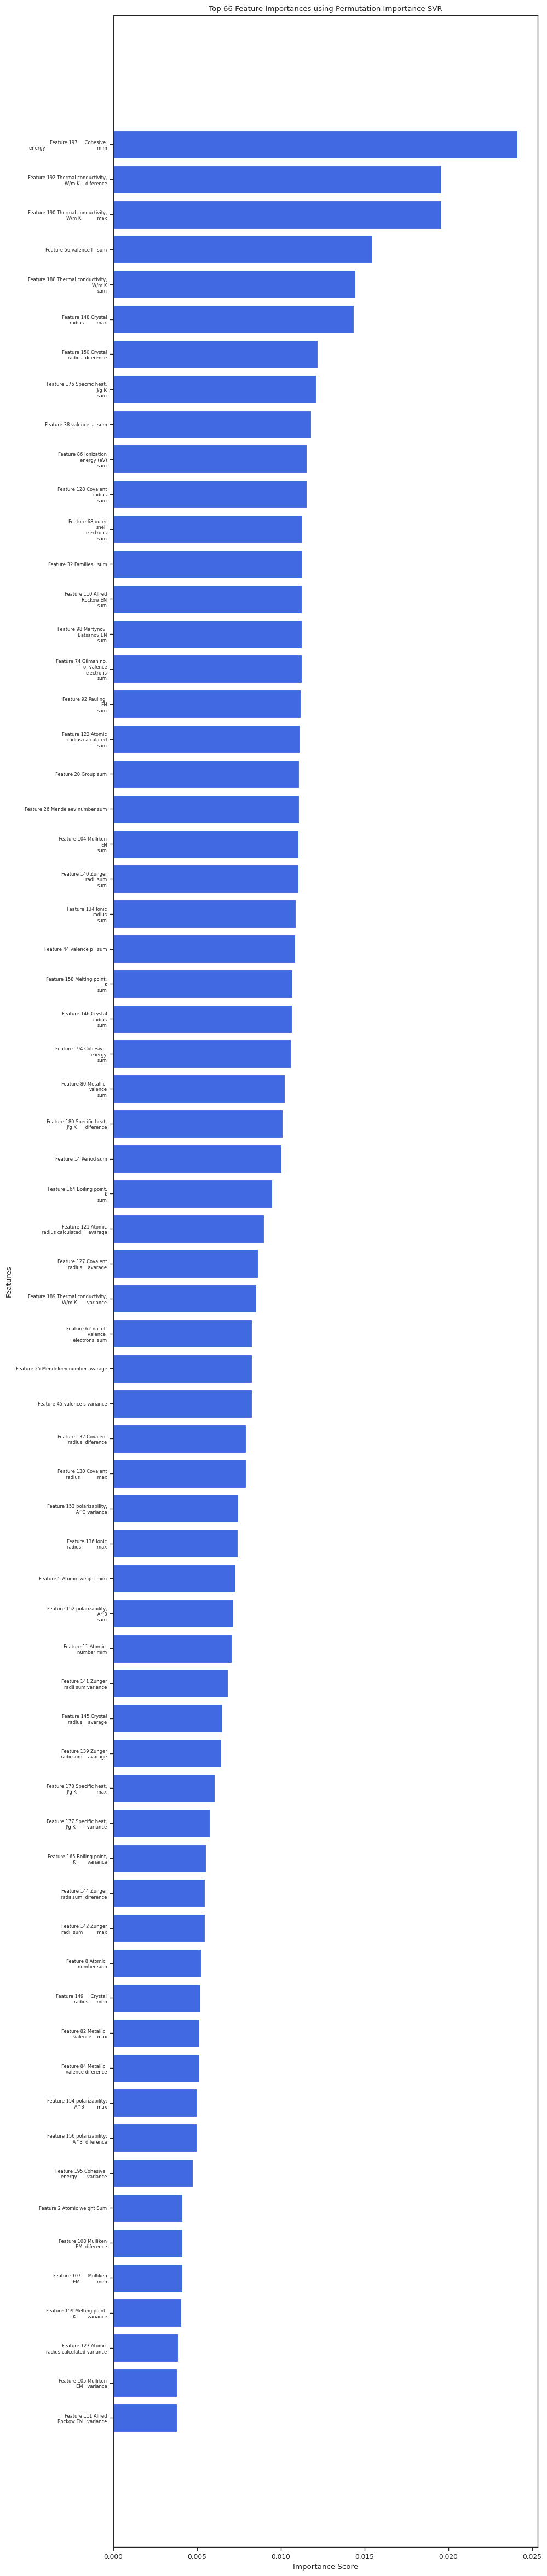

In [ ]:
rf_model = model = SVR(kernel='rbf', C=0.1, epsilon=0.001)
rf_model.fit(X_train, Y_train)
result = permutation_importance(rf_model, X_test, Y_test, n_repeats=10, random_state=42, scoring='r2')
importances = result.importances_mean
indices = np.argsort(importances)[::-1]
feature_names = dataset.drop(columns=['Composition', 'Feature 216   Concentration 2 '], axis=1).columns
N = 66
top_indices = indices[:N]
top_importances = importances[top_indices]
top_features = np.array(feature_names)[top_indices]
plt.figure(figsize=(10, 60))
plt.barh(range(N), top_importances, align="center", color="royalblue")
plt.yticks(range(N), top_features, fontsize=6)
plt.savefig("feature_importance.pdf", bbox_inches="tight")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title(f"Top {N} Feature Importances using Permutation Importance SVR")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
top2_features = top_features
selected_features = top2_features.tolist() + ['Feature 216   Concentration 2 ']
feat_selected = dataset[selected_features]
feat_selected

,Feature 197 Cohesive \nenergy mim,"Feature 192 Thermal conductivity,\nW/m K diference","Feature 190 Thermal conductivity,\nW/m K max",Feature 56 valence f sum,"Feature 188 Thermal conductivity,\nW/m K\nsum",Feature 148 Crystal\nradius max,Feature 150 Crystal\nradius diference,"Feature 176 Specific heat,\nJ/g K\nsum",Feature 38 valence s sum,Feature 86 Ionization\nenergy (eV)\nsum,...,"Feature 156 polarizability,\n A^3 diference",Feature 195 Cohesive \nenergy variance,Feature 2 Atomic weight Sum,Feature 108 Mulliken\nEM diference,Feature 107 Mulliken\nEM mim,"Feature 159 Melting point,\nK variance",Feature 123 Atomic\nradius calculated variance,Feature 105 Mulliken\nEM variance,Feature 111 Allred\nRockow EN variance,Feature 216 Concentration 2
0,1.113,199.97326,200.0,0,765.89132,1.21,0.90,26.73,54,334.7156,...,22.807,1.408573,605.868844,5.34,2.20,1.579695e+05,0.589280,7.015536,1.574055,0.040
1,2.030,35.27326,35.3,14,58.08022,1.49,0.63,3.16,10,54.9049,...,17.107,5.257160,346.422200,3.90,3.64,6.667498e+05,0.703264,7.965984,1.801457,0.070
2,1.840,236.97326,237.0,0,1074.16044,1.21,0.68,9.21,22,112.0198,...,22.007,1.883520,270.193478,5.34,2.20,2.457204e+05,0.558880,7.696064,1.774603,0.040
3,1.840,199.97326,200.0,0,698.34762,1.36,0.96,15.48,42,229.9112,...,30.307,2.978616,887.948700,5.34,2.20,4.453966e+05,0.604504,6.406416,1.451182,0.040
4,2.620,17.17326,17.2,0,17.54196,1.21,0.90,4.75,12,71.1764,...,21.907,3.202184,183.877202,4.35,3.19,4.779250e+05,0.624384,9.029520,1.922010,0.050
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,1.720,35.27326,35.3,14,56.60696,1.32,0.24,4.44,14,72.4669,...,26.807,2.516064,466.117600,5.54,2.00,4.330389e+05,1.091080,7.701536,1.746731,0.040
116,1.113,140.97326,141.0,0,230.46044,1.32,1.07,9.09,19,109.1386,...,26.807,3.889327,228.228168,5.54,2.00,7.681615e+05,0.694936,6.346744,1.538444,0.005
117,1.720,199.97326,200.0,0,383.40696,1.32,0.92,5.32,14,74.4322,...,26.807,2.254816,219.781100,5.54,2.00,4.258203e+05,0.695704,6.785696,1.476115,0.100
118,1.350,115.97326,116.0,0,351.31392,1.21,0.47,16.51,26,149.6067,...,23.507,2.605160,350.858200,4.53,3.01,4.922000e+05,0.490304,5.907240,1.414066,0.080


In [ ]:
X2 = feat_selected.drop(columns=['Feature 216   Concentration 2 '])
Y2 = feat_selected['Feature 216   Concentration 2 ']

In [ ]:
X2_train, X2_test, Y2_train, Y2_test = train_test_split(X2, Y2, test_size=0.2, random_state=46)

In [ ]:
scaler = StandardScaler()
X2_train = scaler.fit_transform(X2_train)
X2_test = scaler.transform(X2_test)

In [ ]:
train_score = []
test_score = []
r2_test = []
C = [100,50,10,5,3,1,0.1,0.3,0.5]
nu = [1,0.1,0.3,0.01,0.03,0.001]
for x in C:
  for y in nu:
    modelo = NuSVR(kernel='rbf', C=x, nu=y)
    modelo.fit(X2_train, Y2_train)
    y_pred = modelo.predict(X2_test)
    train_score.append(modelo.score(X2_train, Y2_train))
    test_score.append(modelo.score(X2_test, Y2_test))
    r2_test.append(r2_score(Y2_test, y_pred))
    print(f'C: {x}, nu: {y}, test_score: {modelo.score(X2_test, Y2_test)}, train_score: {modelo.score(X2_train, Y2_train)}, r_2 : {r2_score(Y2_test, y_pred)}, MSE : {mean_squared_error(Y2_test, y_pred)}')

C: 100, nu: 1, test_score: 0.7019312640372233, train_score: 0.9804923228675141, r_2 : 0.7019312640372233, MSE : 0.000340450384357484
C: 100, nu: 0.1, test_score: 0.7022536249795304, train_score: 0.9801643530699824, r_2 : 0.7022536249795304, MSE : 0.00034008218771869276
C: 100, nu: 0.3, test_score: 0.7005816246416885, train_score: 0.9802557343221421, r_2 : 0.7005816246416885, MSE : 0.0003419919256045714
C: 100, nu: 0.01, test_score: 0.46331373070826065, train_score: 0.5086983353869818, r_2 : 0.46331373070826065, MSE : 0.0006129963482066586
C: 100, nu: 0.03, test_score: 0.7020566443808577, train_score: 0.9800390320198591, r_2 : 0.7020566443808577, MSE : 0.0003403071764962391
C: 100, nu: 0.001, test_score: 0.46628575968390384, train_score: 0.5114365840367746, r_2 : 0.46628575968390384, MSE : 0.0006096017338610411
C: 50, nu: 1, test_score: 0.7014262599493983, train_score: 0.9804302913279529, r_2 : 0.7014262599493983, MSE : 0.0003410271937140466
C: 50, nu: 0.1, test_score: 0.702058763486983

In [ ]:
train_score = []
test_score = []
r2_test = []
C = [100,50,10,5,3,1,0.1,0.001,0.0001]
epsilon = [1,0.1,0.01,0.001]
for x in C:
  for y in epsilon:
    model = SVR(kernel='rbf', C=x, epsilon=y)
    model.fit(X2_train, Y2_train)
    y_pred = model.predict(X2_test)
    train_score.append(model.score(X2_train, Y2_train))
    test_score.append(model.score(X2_test, Y2_test))
    r2_test.append(r2_score(Y2_test, y_pred))
    print(f'C: {x}, epsilon: {y}, test_score: {model.score(X2_test, Y2_test)}, train_score: {model.score(X2_train, Y2_train)}, r_2 : {r2_score(Y2_test, y_pred)}, MSE : {mean_squared_error(Y2_test, y_pred)}')


C: 100, epsilon: 1, test_score: -0.0013679890560873709, train_score: -0.0028992452378096, r_2 : -0.0013679890560873709, MSE : 0.00114375
C: 100, epsilon: 0.1, test_score: -0.001367989056087593, train_score: -0.002899245237809822, r_2 : -0.001367989056087593, MSE : 0.00114375
C: 100, epsilon: 0.01, test_score: 0.6820329759467147, train_score: 0.8685336678183161, r_2 : 0.6820329759467147, MSE : 0.00036317796028586174
C: 100, epsilon: 0.001, test_score: 0.7043238011651727, train_score: 0.9789365467951818, r_2 : 0.7043238011651727, MSE : 0.0003377176583566545
C: 50, epsilon: 1, test_score: -0.0013679890560873709, train_score: -0.0028992452378096, r_2 : -0.0013679890560873709, MSE : 0.00114375
C: 50, epsilon: 0.1, test_score: -0.001367989056087593, train_score: -0.002899245237809822, r_2 : -0.001367989056087593, MSE : 0.00114375
C: 50, epsilon: 0.01, test_score: 0.6808889896327599, train_score: 0.8676728046852514, r_2 : 0.6808889896327599, MSE : 0.00036448460715383214
C: 50, epsilon: 0.001,

In [ ]:
svr1 = NuSVR(kernel='rbf', C=0.3, nu=1)
svr1.fit(X2_train, Y2_train)
svr1.score(X2_test, Y2_test), svr1.score(X2_train, Y2_train)

(0.7049802315047209, 0.7553449741540664)

In [ ]:
loo = LeaveOneOut()
model = svr1
model.fit(X2_train, Y2_train)
scores = cross_val_score(model, X2_test, Y2_test, cv=loo,scoring='neg_mean_squared_error')
print(scores)
print(np.mean(scores))

[-5.00196173e-04 -2.84385043e-05 -2.10823863e-03 -2.74810391e-06
 -1.92395352e-03 -4.20341164e-03 -7.29396827e-04 -7.34190235e-04
 -1.59726932e-03 -1.97252386e-03 -2.34100244e-04 -4.00760251e-04
 -1.70691560e-03 -4.58189083e-04 -2.87289712e-04 -2.34446227e-03
 -6.48968349e-04 -2.77457357e-03 -3.23216230e-03 -1.15292440e-03
 -2.86306617e-04 -3.56708715e-04 -4.19817299e-03 -2.01227517e-03]
-0.0014122573371606398


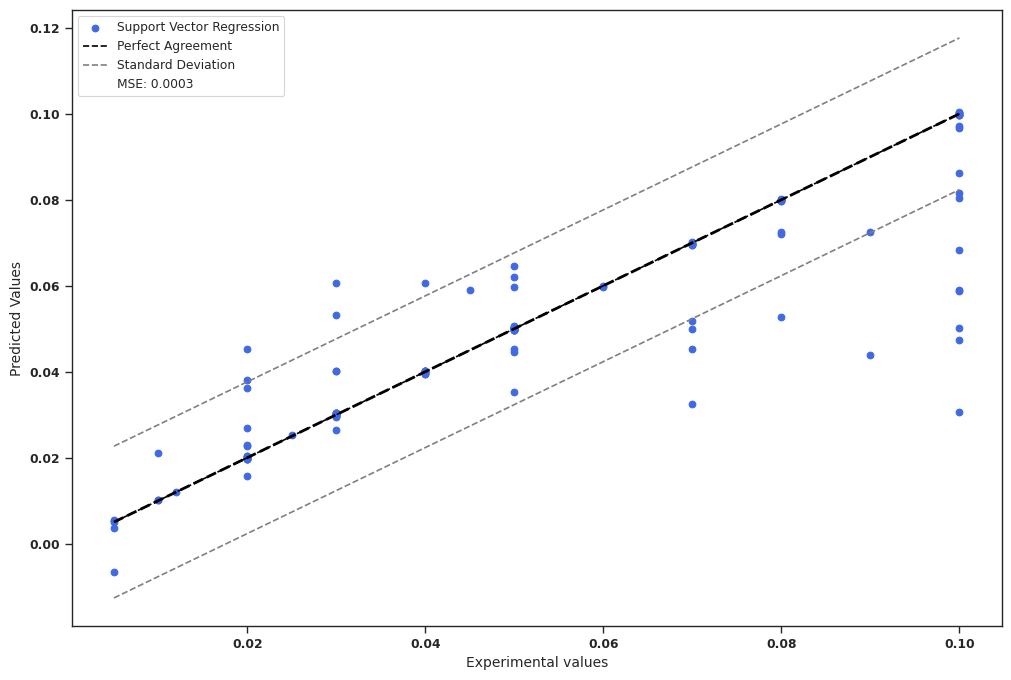

In [ ]:
y_pred = svr1.predict(X2_test)
y_pred_train = svr1.predict(X2_train)
residuos = Y2_test - y_pred
residuo_std = np.std(residuos)
min_val = min(min(Y2_train), min(Y2_test))
max_val = max(max(Y2_train), max(Y2_test))
x = np.linspace(min_val, max_val, 100)
plt.figure(figsize=(12, 8))
ax = plt.gca()
plt.scatter(Y2_train, y_pred_train, color='royalblue', label='Support Vector Regression')
plt.scatter(Y2_test, y_pred, color='royalblue')
plt.plot(x, x, color='black', linestyle='--', label='Perfect Agreement')
plt.plot(x, x + residuo_std, color='grey', linestyle='--', label='Standard Deviation')
plt.plot(x, x - residuo_std, color='grey', linestyle='--')
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2)
plt.xlabel('Experimental values', fontsize=10)
plt.ylabel('Predicted Values', fontsize=10)

for label in ax.get_xticklabels():
    label.set_fontweight('bold')

for label in ax.get_yticklabels():
    label.set_fontweight('bold')

mse = mean_squared_error(Y2_test, y_pred)

from matplotlib.lines import Line2D
mse_label = f'MSE: {mse:.4f}'
mse_line = Line2D([], [], color='none', label=mse_label)

handles, labels = ax.get_legend_handles_labels()

handles.append(mse_line)
labels.append(mse_label)

ax.legend(handles=handles, labels=labels)
plt.show()

In [ ]:
top3_features = top_features
selected_features = top3_features.tolist() + ['Feature 216   Concentration 2 ', 'Feature 199 Space group number ']
feat2_selected = dataset[selected_features]
feat2_selected

,Feature 197 Cohesive \nenergy mim,"Feature 192 Thermal conductivity,\nW/m K diference","Feature 190 Thermal conductivity,\nW/m K max",Feature 56 valence f sum,"Feature 188 Thermal conductivity,\nW/m K\nsum",Feature 148 Crystal\nradius max,Feature 150 Crystal\nradius diference,"Feature 176 Specific heat,\nJ/g K\nsum",Feature 38 valence s sum,Feature 86 Ionization\nenergy (eV)\nsum,...,Feature 195 Cohesive \nenergy variance,Feature 2 Atomic weight Sum,Feature 108 Mulliken\nEM diference,Feature 107 Mulliken\nEM mim,"Feature 159 Melting point,\nK variance",Feature 123 Atomic\nradius calculated variance,Feature 105 Mulliken\nEM variance,Feature 111 Allred\nRockow EN variance,Feature 216 Concentration 2,Feature 199 Space group number
0,1.113,199.97326,200.0,0,765.89132,1.21,0.90,26.73,54,334.7156,...,1.408573,605.868844,5.34,2.20,1.579695e+05,0.589280,7.015536,1.574055,0.040,15
1,2.030,35.27326,35.3,14,58.08022,1.49,0.63,3.16,10,54.9049,...,5.257160,346.422200,3.90,3.64,6.667498e+05,0.703264,7.965984,1.801457,0.070,55
2,1.840,236.97326,237.0,0,1074.16044,1.21,0.68,9.21,22,112.0198,...,1.883520,270.193478,5.34,2.20,2.457204e+05,0.558880,7.696064,1.774603,0.040,221
3,1.840,199.97326,200.0,0,698.34762,1.36,0.96,15.48,42,229.9112,...,2.978616,887.948700,5.34,2.20,4.453966e+05,0.604504,6.406416,1.451182,0.040,176
4,2.620,17.17326,17.2,0,17.54196,1.21,0.90,4.75,12,71.1764,...,3.202184,183.877202,4.35,3.19,4.779250e+05,0.624384,9.029520,1.922010,0.050,141
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,1.720,35.27326,35.3,14,56.60696,1.32,0.24,4.44,14,72.4669,...,2.516064,466.117600,5.54,2.00,4.330389e+05,1.091080,7.701536,1.746731,0.040,62
116,1.113,140.97326,141.0,0,230.46044,1.32,1.07,9.09,19,109.1386,...,3.889327,228.228168,5.54,2.00,7.681615e+05,0.694936,6.346744,1.538444,0.005,1
117,1.720,199.97326,200.0,0,383.40696,1.32,0.92,5.32,14,74.4322,...,2.254816,219.781100,5.54,2.00,4.258203e+05,0.695704,6.785696,1.476115,0.100,62
118,1.350,115.97326,116.0,0,351.31392,1.21,0.47,16.51,26,149.6067,...,2.605160,350.858200,4.53,3.01,4.922000e+05,0.490304,5.907240,1.414066,0.080,212


In [ ]:
X3 = feat2_selected.drop(columns=['Feature 216   Concentration 2 '])
Y3 = feat2_selected['Feature 216   Concentration 2 ']

In [ ]:
X3_train, X3_test, Y3_train, Y3_test = train_test_split(X3, Y3, test_size=0.2, random_state=46)

In [ ]:
scaler = StandardScaler()
X3_train = scaler.fit_transform(X3_train)
X3_test = scaler.transform(X3_test)

In [ ]:
train_score = []
test_score = []
r2_test = []
C = [100,50,10,5,3,1,0.1,0.3,0.5]
nu = [1,0.1,0.3,0.01,0.03,0.001]
for x in C:
  for y in nu:
    modelo = NuSVR(kernel='rbf', C=x, nu=y)
    modelo.fit(X3_train, Y3_train)
    y_pred = modelo.predict(X3_test)
    train_score.append(modelo.score(X3_train, Y3_train))
    test_score.append(modelo.score(X3_test, Y3_test))
    r2_test.append(r2_score(Y3_test, y_pred))
    print(f'C: {x}, nu: {y}, test_score: {modelo.score(X3_test, Y3_test)}, train_score: {modelo.score(X3_train, Y3_train)}, r_2 : {r2_score(Y3_test, y_pred)}, MSE : {mean_squared_error(Y3_test, y_pred)}')

C: 100, nu: 1, test_score: 0.5330640579037387, train_score: 0.9998782872760106, r_2 : 0.5330640579037387, MSE : 0.0005333283963630735
C: 100, nu: 0.1, test_score: 0.53700566151986, train_score: 0.9997335459632607, r_2 : 0.53700566151986, MSE : 0.0005288263459827849
C: 100, nu: 0.3, test_score: 0.5375708669478678, train_score: 0.9997764826418593, r_2 : 0.5375708669478678, MSE : 0.0005281807754079822
C: 100, nu: 0.01, test_score: 0.5380062723502627, train_score: 0.9996819724526294, r_2 : 0.5380062723502627, MSE : 0.0005276834607999345
C: 100, nu: 0.03, test_score: 0.537317311828127, train_score: 0.9996749861038929, r_2 : 0.537317311828127, MSE : 0.0005284703828963112
C: 100, nu: 0.001, test_score: 0.5679276915206661, train_score: 0.6707847259767402, r_2 : 0.5679276915206661, MSE : 0.0004935075898412391
C: 50, nu: 1, test_score: 0.5337211661740235, train_score: 0.999884759444876, r_2 : 0.5337211661740235, MSE : 0.0005325778555106075
C: 50, nu: 0.1, test_score: 0.5373347647796836, train_sc

In [ ]:
train_score = []
test_score = []
r2_test = []
C = [100,50,10,5,3,1,0.1,0.001,0.0001]
epsilon = [1,0.1,0.01,0.001]
for x in C:
  for y in epsilon:
    modelo = SVR(kernel='rbf', C=x, epsilon=y)
    modelo.fit(X3_train, Y3_train)
    y_pred = modelo.predict(X3_test)
    train_score.append(modelo.score(X3_train, Y3_train))
    test_score.append(modelo.score(X3_test, Y3_test))
    r2_test.append(r2_score(Y3_test, y_pred))
    print(f'C: {x}, epsilon: {y}, test_score: {modelo.score(X3_test, Y3_test)}, train_score: {modelo.score(X3_train, Y3_train)}, r_2 : {r2_score(Y3_test, y_pred)}, MSE : {mean_squared_error(Y3_test, y_pred)}')

C: 100, epsilon: 1, test_score: -0.0013679890560873709, train_score: -0.0028992452378096, r_2 : -0.0013679890560873709, MSE : 0.00114375
C: 100, epsilon: 0.1, test_score: -0.001367989056087593, train_score: -0.002899245237809822, r_2 : -0.001367989056087593, MSE : 0.00114375
C: 100, epsilon: 0.01, test_score: 0.6114626195014103, train_score: 0.8809092457565804, r_2 : 0.6114626195014103, MSE : 0.0004437825392882329
C: 100, epsilon: 0.001, test_score: 0.5469443046338027, train_score: 0.998443253146623, r_2 : 0.5469443046338027, MSE : 0.0005174745520510784
C: 50, epsilon: 1, test_score: -0.0013679890560873709, train_score: -0.0028992452378096, r_2 : -0.0013679890560873709, MSE : 0.00114375
C: 50, epsilon: 0.1, test_score: -0.001367989056087593, train_score: -0.002899245237809822, r_2 : -0.001367989056087593, MSE : 0.00114375
C: 50, epsilon: 0.01, test_score: 0.6114626195014103, train_score: 0.8809092457565804, r_2 : 0.6114626195014103, MSE : 0.0004437825392882329
C: 50, epsilon: 0.001, te

In [ ]:
svr2 = NuSVR(kernel='rbf', C=0.2, nu=1)
svr2.fit(X3_train, Y3_train)
svr2.score(X3_test, Y3_test), svr2.score(X3_train, Y3_train)

(0.6709135023169828, 0.7121906207665747)

In [ ]:
loo = LeaveOneOut()
model = svr2
model.fit(X2_train, Y2_train)
scores = cross_val_score(model, X2_test, Y2_test, cv=loo,scoring='neg_mean_squared_error')
print(scores)
print(np.mean(scores))

[-5.01463072e-04 -2.70534086e-07 -2.38521901e-03 -9.83493206e-06
 -2.52699156e-03 -4.27626658e-03 -8.06386190e-04 -9.03650545e-04
 -1.42636760e-03 -2.28235909e-03 -2.31644826e-04 -3.98200992e-04
 -2.00522773e-03 -7.10281373e-04 -3.05142908e-04 -2.29369270e-03
 -8.02892558e-04 -2.68060576e-03 -3.19728443e-03 -1.24615687e-03
 -6.30549844e-04 -4.84714917e-04 -4.15620244e-03 -2.00727763e-03]
-0.0015111951705623775


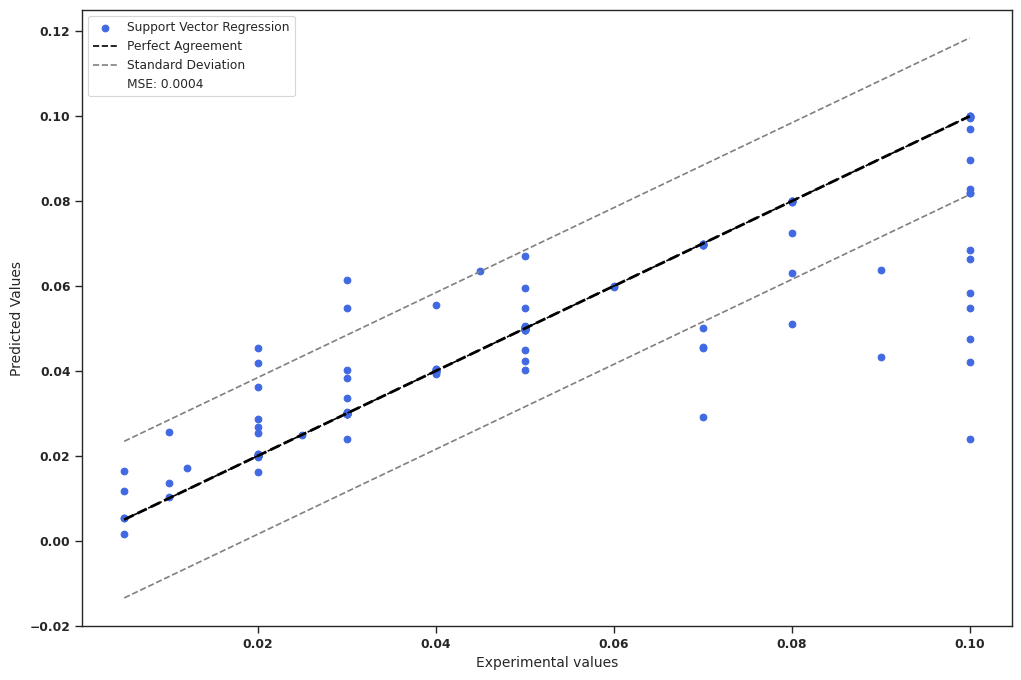

In [ ]:
y_pred = svr2.predict(X2_test)
y_pred_train = svr2.predict(X2_train)
residuos = Y2_test - y_pred
residuo_std = np.std(residuos)
min_val = min(min(Y2_train), min(Y2_test))
max_val = max(max(Y2_train), max(Y2_test))
x = np.linspace(min_val, max_val, 100)
plt.figure(figsize=(12, 8))
ax = plt.gca()
plt.scatter(Y2_train, y_pred_train, color='royalblue', label='Support Vector Regression')
plt.scatter(Y2_test, y_pred, color='royalblue')
plt.plot(x, x, color='black', linestyle='--', label='Perfect Agreement')
plt.plot(x, x + residuo_std, color='grey', linestyle='--', label='Standard Deviation')
plt.plot(x, x - residuo_std, color='grey', linestyle='--')
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2)
plt.xlabel('Experimental values', fontsize=10)
plt.ylabel('Predicted Values', fontsize=10)

for label in ax.get_xticklabels():
    label.set_fontweight('bold')

for label in ax.get_yticklabels():
    label.set_fontweight('bold')

mse = mean_squared_error(Y2_test, y_pred)

from matplotlib.lines import Line2D
mse_label = f'MSE: {mse:.4f}'
mse_line = Line2D([], [], color='none', label=mse_label)

handles, labels = ax.get_legend_handles_labels()

handles.append(mse_line)
labels.append(mse_label)

ax.legend(handles=handles, labels=labels)
plt.show()

In [ ]:
up = files.upload()

Saving Prevision_Materials.xlsx to Prevision_Materials.xlsx


In [ ]:
materials = pd.read_excel('Prevision_Materials.xlsx', sheet_name='Features', engine='openpyxl')
selected_features = ['Composition'] + [feature for feature in top3_features if feature in materials.columns] + ['Feature 204   Concentration 2 ', 'Feature 199 Space group number ']
materials_selected = materials[selected_features]
materials_selected

,Composition,Feature 197 Cohesive \nenergy mim,"Feature 192 Thermal conductivity,\nW/m K diference","Feature 190 Thermal conductivity,\nW/m K max",Feature 56 valence f sum,"Feature 188 Thermal conductivity,\nW/m K\nsum",Feature 148 Crystal\nradius max,Feature 150 Crystal\nradius diference,"Feature 176 Specific heat,\nJ/g K\nsum",Feature 38 valence s sum,...,Feature 195 Cohesive \nenergy variance,Feature 2 Atomic weight Sum,Feature 108 Mulliken\nEM diference,Feature 107 Mulliken\nEM mim,"Feature 159 Melting point,\nK variance",Feature 123 Atomic\nradius calculated variance,Feature 105 Mulliken\nEM variance,Feature 111 Allred\nRockow EN variance,Feature 204 Concentration 2,Feature 199 Space group number
0,YVO4,2.62,30.67326,30.7,0,48.00696,1.21,0.53,4.470,12,...,4.779880,203.844940,4.35,3.19,9.371702e+05,0.786736,7.783584,1.757976,0,141
1,Y3Al5O12,2.62,236.97326,237.0,0,1236.92088,1.21,0.68,16.440,40,...,3.180904,593.618015,4.35,3.19,5.099469e+05,0.651904,7.696856,1.768308,0,230
2,LiSrPO4,1.63,84.67326,84.7,0,120.34196,1.32,1.01,8.350,13,...,1.314520,189.532362,5.54,2.00,1.395569e+05,0.623064,7.093264,1.578379,0,170
3,YPO4,2.62,17.17326,17.2,0,17.54196,1.21,0.90,4.750,12,...,3.202184,183.877202,4.35,3.19,4.779250e+05,0.624384,9.029520,1.922010,0,141
4,LiBaPO4,1.63,84.67326,84.7,0,103.44196,1.49,1.18,8.254,13,...,1.308184,239.239362,5.14,2.40,1.280995e+05,0.794696,6.857424,1.598629,0,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304,Sr2Ta2O7,1.72,57.47326,57.5,28,185.78718,1.32,0.54,7.320,22,...,8.896416,649.131600,5.54,2.00,1.592787e+06,0.932944,8.095840,1.752471,0,63
305,LaB3O6,2.62,26.97326,27.0,0,94.66044,1.36,1.11,8.770,20,...,5.463880,267.334900,4.44,3.10,8.734284e+05,0.522360,8.056944,1.862320,0,15
306,CaMgB2O5,1.51,199.97326,200.0,0,410.13370,1.21,0.96,8.290,18,...,3.706504,166.002000,5.34,2.20,7.355988e+05,0.471976,6.186504,1.443615,0,14
307,CaMgB2O5,1.51,199.97326,200.0,0,410.13370,1.21,0.96,8.290,18,...,3.706504,166.002000,5.34,2.20,7.355988e+05,0.471976,6.186504,1.443615,0,61


In [ ]:
materials_selected = materials_selected.drop(columns=['Feature 204   Concentration 2 ','Composition'])

In [ ]:
materials_selected = scaler.transform(materials_selected)

In [ ]:
svr2 = NuSVR(kernel='rbf', C=0.2, nu=1)
svr2.fit(X3_train, Y3_train)
svr2.score(X3_test, Y3_test), svr2.score(X3_train, Y3_train)

(0.6709135023169828, 0.7121906207665747)

In [ ]:
for i in range(len(materials)):
    prediction = svr2.predict(materials_selected[[i]])
    material = materials['Composition'][i]
    print(f"{material} : {prediction[0]}")

YVO4 : 0.05018355040641036
Y3Al5O12 : 0.06819519337840449
LiSrPO4 : 0.0402544127535658
YPO4 : 0.049768295435771465
LiBaPO4 : 0.03217546599679824
LiBaPO4 : 0.03468545998885691
GdVO4 : 0.07700183040935887
Sc2Mo3O12 : 0.05876870649199204
Bi4Ti3O12 : 0.03476492823070944
Bi4Ti3O12 : 0.03125870496122428
Bi4Ti3O12 : 0.036292190850866365
Lu3Al5O12 : 0.10002285812340936
Lu3Al2Ga3O12 : 0.08378957386415055
Zn2TiO4 : 0.014799635219528179
Zn2TiO4 : 0.020894008758359332
K3YB6O12 : 0.019807967501740173
Bi2Mo3O12 : 0.040049322756436315
Sr4Ca2W2O12 : 0.11131472904544516
Li2GeTeO6 : 0.061704509751771525
Li2GeTeO6 : 0.059369889111561026
LiGa5O8 : 0.05755234996841557
SrTiO3 : 0.0505192170217503
SrTiO3 : 0.0520321525853831
CaTiO3 : 0.04158897197353946
CaTiO3 : 0.03328287850184574
Al2BeO4 : 0.054537187836147055
Bi2Al4O9 : 0.0669856622102777
Bi2Ga4O9 : 0.034275703887858125
Al2O3 : 0.04474645127403991
Al2O3 : 0.04661992400805069
Al2O3 : 0.04425184535951376
GdAlO3 : 0.043896903723776574
GdAlO3 : 0.037333770415